In [65]:
import sys
print(sys.executable)

c:\Users\yash2\AppData\Local\Programs\Python\Python311\python.exe


In [66]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Keras Models & Layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dense,
    Dropout,
    BatchNormalization,
    Flatten,
    RandomFlip,
    RandomRotation,
    RandomZoom,
    Rescaling
)

# Optimizers & Callbacks
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [67]:
import os
# Walk through pizza_steak directory and list number of files
print("Train data: ")
for dirpath, dirnames, filenames in os.walk("seg_train"):
  print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")
print("Test data: ")
for dirpath, dirnames, filenames in os.walk("seg_test"):
  print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")
print("Prediction data: ")
for dirpath, dirnames, filenames in os.walk("seg_pred"):
  print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

Train data: 
There are 6 directories and 0 images in 'seg_train'.
There are 0 directories and 2191 images in 'seg_train\buildings'.
There are 0 directories and 2271 images in 'seg_train\forest'.
There are 0 directories and 2404 images in 'seg_train\glacier'.
There are 0 directories and 2512 images in 'seg_train\mountain'.
There are 0 directories and 2274 images in 'seg_train\sea'.
There are 0 directories and 2382 images in 'seg_train\street'.
Test data: 
There are 6 directories and 0 images in 'seg_test'.
There are 0 directories and 437 images in 'seg_test\buildings'.
There are 0 directories and 474 images in 'seg_test\forest'.
There are 0 directories and 553 images in 'seg_test\glacier'.
There are 0 directories and 525 images in 'seg_test\mountain'.
There are 0 directories and 510 images in 'seg_test\sea'.
There are 0 directories and 501 images in 'seg_test\street'.
Prediction data: 


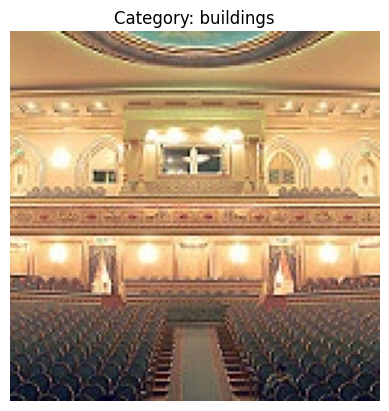

Image shape: (150, 150, 3)


In [68]:
%matplotlib inline
# Choose which category you want to see
target_folder = 'buildings'
folder_path = f'seg_train/{target_folder}' # Path depends on how it unzipped

# Get a list of all image names in that folder
images = os.listdir(folder_path)

# Pick a random image from the list
random_image = random.choice(images)

# Read and show the image
img = mpimg.imread(os.path.join(folder_path, random_image))
plt.imshow(img)
plt.title(f"Category: {target_folder}")
plt.axis('off')
plt.show()

print(f"Image shape: {img.shape}")

In [69]:
def view_random_image(target_dir, target_class):
  # We will view image from here
  target_folder = target_dir + target_class

  # Get a random image path
  random_image = random.sample(os.listdir(target_folder), 1)

  # Read in the image and plot it using matplotlib
  img = mpimg.imread(target_folder+'/'+random_image[0])
  plt.imshow(img)
  plt.title(target_class)
  plt.axis('off');
  print(f"Image shape {img.shape}")

  return img

Image shape (150, 150, 3)


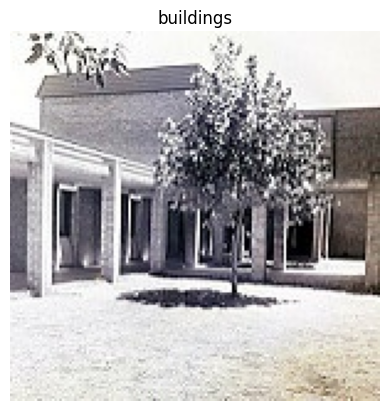

In [70]:
img = view_random_image(target_dir='seg_train/',
                  target_class='buildings')

In [71]:
import pathlib
data_dir = pathlib.Path("seg_train")
class_names = np.array(sorted([item.name for item in data_dir.glob('*')]))
print(class_names)

['buildings' 'forest' 'glacier' 'mountain' 'sea' 'street']


Image shape (150, 150, 3)
Image shape (150, 150, 3)
Image shape (150, 150, 3)
Image shape (150, 150, 3)
Image shape (150, 150, 3)
Image shape (150, 150, 3)
Image shape (150, 150, 3)
Image shape (150, 150, 3)
Image shape (150, 150, 3)
Image shape (150, 150, 3)
Image shape (150, 150, 3)
Image shape (150, 150, 3)
Image shape (150, 150, 3)
Image shape (150, 150, 3)
Image shape (150, 150, 3)
Image shape (150, 150, 3)
Image shape (150, 150, 3)
Image shape (150, 150, 3)
Image shape (150, 150, 3)
Image shape (150, 150, 3)
Image shape (150, 150, 3)
Image shape (150, 150, 3)
Image shape (150, 150, 3)
Image shape (150, 150, 3)


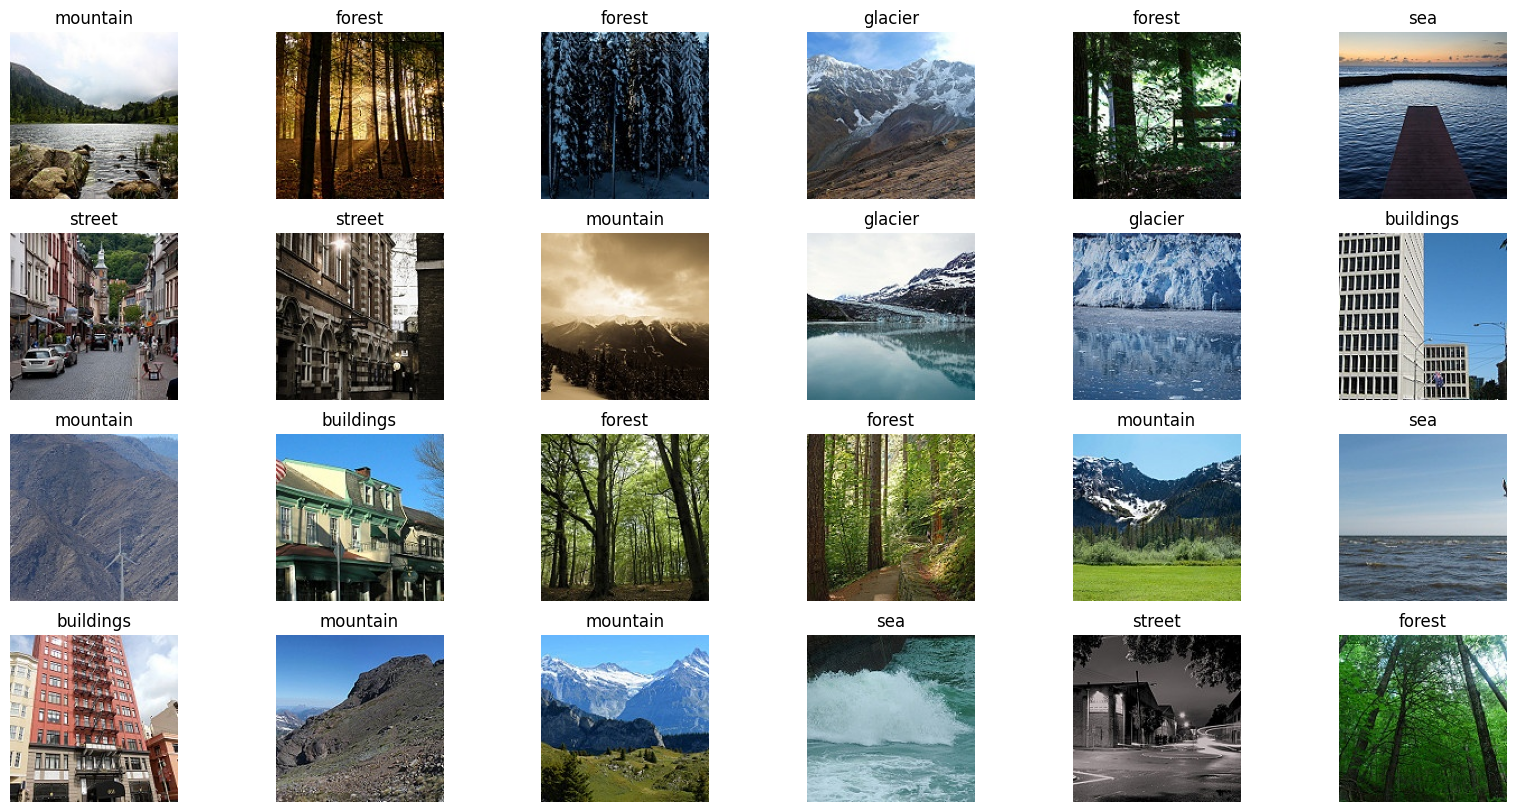

In [72]:
plt.figure(figsize=(20, 10))
for i in range(24):
  plt.subplot(4, 6, i+1)
  class_name = random.choice(class_names)
  img = view_random_image(target_dir='seg_train/',
                  target_class=class_name)

In [73]:
train_dir = "seg_train/"
test_dir = "seg_test/"

In [74]:
train_datagen = ImageDataGenerator(
    rescale=1/255.,
    rotation_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    vertical_flip=True
)

val_datagen = ImageDataGenerator(rescale = 1/255.)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size= (150, 150),
    batch_size= 32,
    class_mode= 'categorical'
)

test_data = val_datagen.flow_from_directory(
    test_dir,
    target_size= (150, 150),
    batch_size= 32,
    class_mode= 'categorical'
)

Found 14034 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


In [75]:
model_1 = Sequential([
  Conv2D(16, 3, padding='same', activation='relu', input_shape=(150,150,3)),
  MaxPool2D(),
  Conv2D(32, 3, padding='same', activation='relu'),
  MaxPool2D(),
  Conv2D(64, 3, padding='same', activation='relu'),
  MaxPool2D(),
  Flatten(),
  Dense(128, activation='relu'),
  Dense(len(class_names), activation='softmax')
])

model_1.compile(loss="categorical_crossentropy",
              optimizer=Adam(),
              metrics=['accuracy'])
model_1.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_19 (Conv2D)          (None, 150, 150, 16)      448       
                                                                 
 max_pooling2d_16 (MaxPooli  (None, 75, 75, 16)        0         
 ng2D)                                                           
                                                                 
 conv2d_20 (Conv2D)          (None, 75, 75, 32)        4640      
                                                                 
 max_pooling2d_17 (MaxPooli  (None, 37, 37, 32)        0         
 ng2D)                                                           
                                                                 
 conv2d_21 (Conv2D)          (None, 37, 37, 64)        18496     
                                                                 
 max_pooling2d_18 (MaxPooli  (None, 18, 18, 64)       

In [77]:
history_1 = model_1.fit(train_data,
                    epochs=50,
                    batch_size=32,
                    steps_per_epoch=len(train_data),
                    validation_data=test_data,
                    validation_steps=len(test_data))

Epoch 1/50
439/439 [==============================] - 67s 152ms/step - loss: 1.1113 - accuracy: 0.5552 - val_loss: 0.9208 - val_accuracy: 0.6423
Epoch 2/50
439/439 [==============================] - 64s 146ms/step - loss: 0.8898 - accuracy: 0.6541 - val_loss: 0.9542 - val_accuracy: 0.6473
Epoch 3/50
439/439 [==============================] - 63s 144ms/step - loss: 0.7888 - accuracy: 0.6999 - val_loss: 0.6717 - val_accuracy: 0.7477
Epoch 4/50
439/439 [==============================] - 63s 143ms/step - loss: 0.7126 - accuracy: 0.7310 - val_loss: 0.5825 - val_accuracy: 0.7867
Epoch 5/50
439/439 [==============================] - 63s 144ms/step - loss: 0.6572 - accuracy: 0.7572 - val_loss: 0.6554 - val_accuracy: 0.7697
Epoch 6/50
439/439 [==============================] - 62s 142ms/step - loss: 0.6248 - accuracy: 0.7647 - val_loss: 0.5646 - val_accuracy: 0.7947
Epoch 7/50
439/439 [==============================] - 61s 139ms/step - loss: 0.5940 - accuracy: 0.7783 - val_loss: 0.5634 - val_ac

In [78]:
model_1.evaluate(test_data)

94/94 [==============================] - 6s 67ms/step - loss: 0.4160 - accuracy: 0.8593


[0.4159558117389679, 0.859333336353302]

Text(0, 0.5, 'Loss')

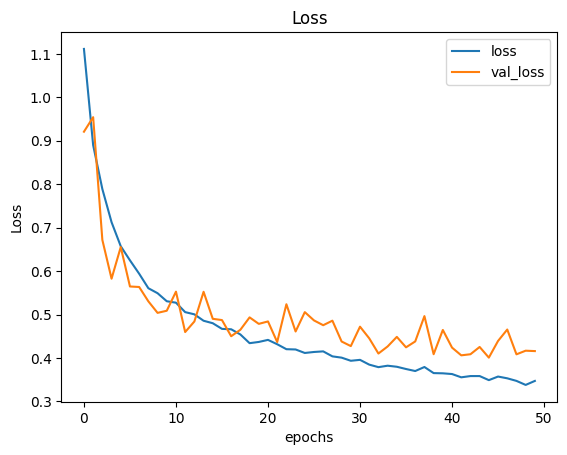

In [79]:
pd.DataFrame(history_1.history)[['loss','val_loss']].plot()
plt.title('Loss')
plt.xlabel('epochs')
plt.ylabel('Loss')

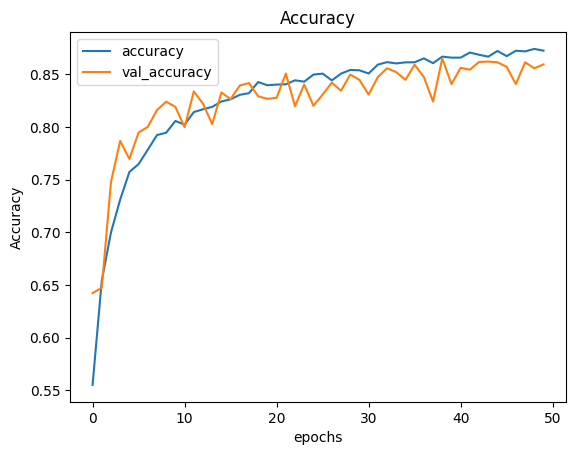

In [84]:
pd.DataFrame(history_1.history)[['accuracy', 'val_accuracy']].plot()
plt.title('Accuracy')
plt.xlabel('epochs')
plt.ylabel('Accuracy');

In [80]:
model_1.save('newmodel1/', save_format='tf')

INFO:tensorflow:Assets written to: newmodel1/assets


INFO:tensorflow:Assets written to: newmodel1/assets
